# Поиск объявлений услуг по запросу (Recall@50)

Для каждого из 2 452 запросов бенчмарка нужно вернуть до 50 объявлений из корпуса (189 212 шт.). Метрика — **Recall@50**.

**Подход** — двухэтапный поиск:

1. **Кандидаты (~350 на запрос)** из пяти источников: TF-IDF по словам, символам и описанию, эмбеддинги `rubert-tiny-turbo` и сигнал «что выбирали по похожим запросам в train». Учитывается приор локации.
2. **Ранжирование** кандидатов моделью CatBoost (YetiRank), топ-50 идёт в ответ.

**Валидация** — псевдо-бенчмарк той же структуры, собранный из train.

**Разделы:** 1. Настройка · 2. Данные · 3. EDA · 4. Валидация · 5. Кандидаты · 6. Ранжирование · 7. Ответ · 8. Описание решения

## 1. Настройка

Зависимости перечислены в `requirements.txt`. Все гиперпараметры собраны в `CFG`.

In [1]:
import os, gc, time, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import torch
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from catboost import CatBoostRanker, Pool

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)

# Все гиперпараметры в одном месте
CFG = dict(
    SEED=42,
    N_VAL=2500,           # размер каждой из валидационных частей A и B
    CORPUS_SIZE=189_212,  # размер валидационного корпуса = размеру корпуса бенчмарка
    DESC_CHARS=600,       # сколько символов описания используем
    BATCH_Q=64,           # сколько запросов скорим за раз (память: BATCH_Q * размер корпуса * 4 байта на матрицу)
    TOP_PER_SOURCE=80,    # кандидатов от каждого источника
    TOP_HYBRID=150,       # кандидатов от взвешенной смеси источников
    N_NEIGH=30,           # сколько похожих train-запросов берём для коллаборативного сигнала
    NEIGH_TEMP=0.1,       # «температура» весов соседей: w = exp((sim - 1) / T)
    EMB_MODEL='models/rubert-tiny-turbo',
    EMB_BATCH=128,
    RANKER_ITERS=800,
)
CACHE = 'cache'
os.makedirs(CACHE, exist_ok=True)
np.random.seed(CFG['SEED'])
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: mps


### Модель эмбеддингов

`sergeyzh/rubert-tiny-turbo` — компактный русскоязычный энкодер (312-мерные эмбеддинги). Скачивается один раз в `models/`, дальше работает локально. Эмбеддинги кэшируются в `cache/`.

In [2]:
if not os.path.exists(os.path.join(CFG['EMB_MODEL'], 'config.json')):
    from huggingface_hub import snapshot_download
    snapshot_download('sergeyzh/rubert-tiny-turbo', local_dir=CFG['EMB_MODEL'])

encoder = SentenceTransformer(CFG['EMB_MODEL'], device=DEVICE)
encoder.max_seq_length = 128

def encode(texts, cache_name):
    """Кодирует тексты в L2-нормированные эмбеддинги; результат кэшируется в cache/*.npy."""
    path = f'{CACHE}/{cache_name}.npy'
    if os.path.exists(path):
        E = np.load(path)
        if len(E) == len(texts):
            return E
    E = encoder.encode(list(texts), batch_size=CFG['EMB_BATCH'], normalize_embeddings=True,
                       convert_to_numpy=True, show_progress_bar=True).astype(np.float32)
    np.save(path, E)
    return E

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

## 2. Загрузка данных

Загружаются только нужные колонки. Описания читаются потоково и обрезаются до `DESC_CHARS` символов.

In [3]:
TRAIN_COLS = ['search_query', 'search_location_id', 'search_is_delivery_search', 'search_infm_params_text',
              'search_category', 'item_id', 'item_title_raw', 'item_infm_params_text', 'item_location_id',
              'item_microcat_id', 'item_category_id', 'item_price', 'item_rating', 'item_rating_reviews_count',
              'item_is_phone_hidden', 'item_is_message_forbidden']
ITEM_COLS = [c for c in TRAIN_COLS if c.startswith('item_')]

def load_desc(path, ids, n_chars):
    """Потоково читает описания и оставляет только нужные item_id (обрезанные до n_chars)."""
    ids = set(ids)
    out = {}
    for batch in pq.ParquetFile(path).iter_batches(columns=['item_id', 'item_description_raw'], batch_size=50_000):
        d = batch.to_pandas()
        d = d[d.item_id.isin(ids)]
        out.update(zip(d.item_id, d.item_description_raw.fillna('').str.slice(0, n_chars)))
    return out

t0 = time.time()
train = pd.read_parquet('train.parquet', columns=TRAIN_COLS)
bench_q = pd.read_parquet('benchmark_queries.parquet')
bench_items = pd.read_parquet('benchmark_items.parquet', columns=ITEM_COLS)
for df in (train, bench_items):
    df['item_price'] = df['item_price'].astype('float64')   # decimal128 -> float
for df in (train, bench_q):
    df['search_infm_params_text'] = df['search_infm_params_text'].fillna('')

bench_items['item_description_raw'] = bench_items.item_id.map(
    load_desc('benchmark_items.parquet', bench_items.item_id, CFG['DESC_CHARS']))
print(f'train {train.shape}, bench_q {bench_q.shape}, bench_items {bench_items.shape}, {time.time()-t0:.0f}s')
print(f'train в памяти: {train.memory_usage(deep=True).sum()/1e9:.2f} ГБ')

train (497673, 16), bench_q (2452, 6), bench_items (189212, 12), 15s
train в памяти: 1.45 ГБ


### Нормализация текста

Нижний регистр, `ё → е`, пунктуация заменяется пробелом.

In [4]:
def norm(s: pd.Series) -> pd.Series:
    return (s.fillna('').str.lower().str.replace('ё', 'е', regex=False)
             .str.replace(r'[^\w\s]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip())

def prepare_items(df: pd.DataFrame) -> pd.DataFrame:
    """Текстовые поля и числовые признаки объявлений."""
    df = df.reset_index(drop=True).copy()
    df['t_title'] = norm(df.item_title_raw)
    df['t_par'] = norm(df.item_infm_params_text)
    df['t_desc'] = norm(df.item_description_raw)
    # Текст для энкодера: заголовок + начало параметров (там «Вид услуги / Тип услуги») + начало описания
    df['t_dense'] = (df.item_title_raw.fillna('') + '. ' + df.item_infm_params_text.fillna('').str.slice(0, 120)
                     + '. ' + df.item_description_raw.fillna('').str.slice(0, 200))
    return df

def prepare_queries(df: pd.DataFrame) -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()
    df['t_q'] = norm(df.search_query)
    df['t_f'] = norm(df.search_infm_params_text)
    return df

train['t_q'] = norm(train.search_query)
bench_q = prepare_queries(bench_q)
bench_q.head()

,query_id,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,t_q,t_f
0,70DfDUpwjxB4lzFd,перевозки владикавказ тбилиси,649820,0,,114,перевозки владикавказ тбилиси,
1,JTrdTaZJvSiLPkXj,обзвон по базе,107620,0,Вид услуги Деловые услуги,114,обзвон по базе,вид услуги деловые услуги
2,LZCZNoVG4AFUkVRJ,липоредукция подбородка,637640,0,"Вид услуги Красота, здоровье",114,липоредукция подбородка,вид услуги красота здоровье
3,660ac9QVtXkRxZC3,подъемник 4 х стоечный,662810,0,,114,подъемник 4 х стоечный,
4,YgHcM9MVbxKnxD1e,монтаж видеодомофонов,642790,0,,114,монтаж видеодомофонов,


## 3. EDA

In [5]:
KEY = ['search_query', 'search_location_id', 'search_is_delivery_search', 'search_infm_params_text', 'search_category']
train['gid'] = train.groupby(KEY, sort=False).ngroup()   # уникальный «запрос» = текст + локация + фильтры + категория
grp_size = train.groupby('gid').item_id.nunique()

bench_ids = set(bench_items.item_id)
train_texts = set(train.t_q)
facts = {
    'строк в train': len(train),
    'уникальных запросов (групп) в train': train.gid.nunique(),
    'релевантных объявлений на группу (среднее)': round(grp_size.mean(), 3),
    'доля пар, где локация объявления = локации поиска': round((train.search_location_id == train.item_location_id).mean(), 3),
    'доля объявлений корпуса, встречающихся в train': round(bench_items.item_id.isin(set(train.item_id)).mean(), 3),
    'доля текстов бенчмарка, встречающихся в train': round(bench_q.t_q.isin(train_texts).mean(), 3),
    'доля top-1 микрокатегории внутри текста запроса': round(train.groupby('t_q').item_microcat_id
                                                            .agg(lambda s: s.value_counts(normalize=True).iloc[0]).mean(), 3),
    'доля train-запросов с фильтрами': round((train.search_infm_params_text != '').mean(), 3),
}
pd.Series(facts, name='значение').to_frame()

,значение
строк в train,497673.000
уникальных запросов (групп) в train,354463.000
релевантных объявлений на группу (среднее),1.318
"доля пар, где локация объявления = локации поиска",0.831
"доля объявлений корпуса, встречающихся в train",0.096
"доля текстов бенчмарка, встречающихся в train",0.375
доля top-1 микрокатегории внутри текста запроса,0.930
доля train-запросов с фильтрами,0.670


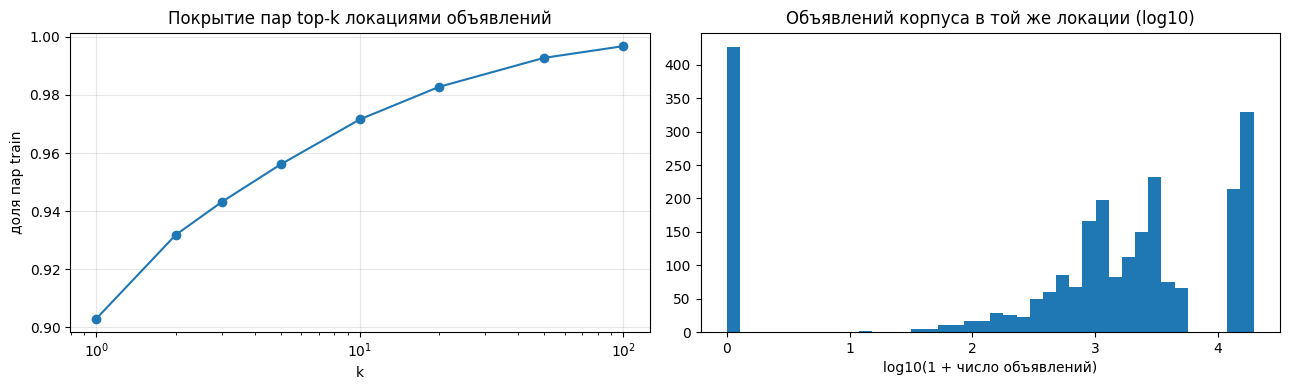

Запросов бенчмарка без объявлений в «своей» локации: 0.174


In [6]:
# Покрытие пар «локация поиска -> локация объявления» топ-k самыми частыми локациями объявлений
m = train.groupby(['search_location_id', 'item_location_id']).size().rename('n').reset_index()
m = m.sort_values(['search_location_id', 'n'], ascending=[True, False])
m['rk'] = m.groupby('search_location_id').cumcount() + 1
ks = [1, 2, 3, 5, 10, 20, 50, 100]
cov = [m[m.rk <= k].n.sum() / len(train) for k in ks]

# Сколько объявлений корпуса приходится на локацию каждого запроса бенчмарка
per_loc = bench_items.item_location_id.value_counts()
pool = bench_q.search_location_id.map(per_loc).fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ks, cov, marker='o'); ax[0].set_xscale('log'); ax[0].grid(alpha=.3)
ax[0].set_title('Покрытие пар top-k локациями объявлений'); ax[0].set_xlabel('k'); ax[0].set_ylabel('доля пар train')
ax[1].hist(np.log10(pool + 1), bins=40); ax[1].set_title('Объявлений корпуса в той же локации (log10)')
ax[1].set_xlabel('log10(1 + число объявлений)')
plt.tight_layout(); plt.show()
print('Запросов бенчмарка без объявлений в «своей» локации:', (pool == 0).mean().round(3))
del m; _ = gc.collect()

**Выводы:**

- В 83% пар локация объявления совпадает с локацией поиска. Но часть запросов задана регионом, и объявлений с таким `location_id` в корпусе нет. Поэтому вместо жёсткого фильтра используется приор `P(локация объявления | локация поиска)` из train.
- Лишь ~10% объявлений корпуса есть в train, зато ~37% текстов запросов бенчмарка там встречаются. Поэтому история поиска используется на уровне похожих запросов, а не item_id.
- Внутри одного текста запроса 93% выборов приходятся на одну микрокатегорию. Отсюда признак «вероятная микрокатегория».
- Фильтры запроса почти дословно повторяются в параметрах выбранного объявления. Отсюда признак совпадения фильтра.

## 4. Локальная валидация

Разметки бенчмарка нет, поэтому из train собирается псевдо-бенчмарк той же структуры:

- запрос = группа train (текст, локация, фильтры, категория), релевантные = выбранные в ней объявления;
- 63% «новых» и 37% «известных» текстов, как в бенчмарке;
- корпус = релевантные + случайные объявления train, всего 189 212;
- часть **A** обучает ранкер, часть **B** служит для оценки;
- `fit` = train без этих запросов и их объявлений, чтобы не было утечки.

In [7]:
rng = np.random.default_rng(CFG['SEED'])
g = train.groupby('gid').agg(t_q=('t_q', 'first')).reset_index()
g['text_groups'] = g.groupby('t_q').gid.transform('size')
g_new = g[g.text_groups == 1]                                                # «новые» тексты
g_known = g[g.text_groups > 1].groupby('t_q').sample(1, random_state=CFG['SEED'])  # одна группа на «известный» текст

n_total = 2 * CFG['N_VAL']
n_new = int(n_total * 0.63)
sel = pd.concat([g_new.sample(n_new, random_state=CFG['SEED']),
                 g_known.sample(n_total - n_new, random_state=CFG['SEED'])]).sample(frac=1, random_state=CFG['SEED'])
gid_A, gid_B = set(sel.gid.iloc[:CFG['N_VAL']]), set(sel.gid.iloc[CFG['N_VAL']:])
val_gids = gid_A | gid_B

val_rows = train[train.gid.isin(val_gids)]
rel_items = set(val_rows.item_id)
fit = train[~train.gid.isin(val_gids) & ~train.item_id.isin(rel_items)]

# Запросы валидации в формате бенчмарка + список релевантных
val_q = (val_rows.groupby('gid')
         .agg(search_query=('search_query', 'first'), search_location_id=('search_location_id', 'first'),
              search_infm_params_text=('search_infm_params_text', 'first'), search_category=('search_category', 'first'),
              rel=('item_id', lambda s: sorted(set(s))))
         .reset_index())
val_q['part'] = np.where(val_q.gid.isin(gid_A), 'A', 'B')
val_q = prepare_queries(val_q)

# Корпус: все релевантные + случайные «отвлекающие» объявления train
uniq_items = train.drop_duplicates('item_id')[ITEM_COLS]
distract = uniq_items[~uniq_items.item_id.isin(rel_items)].sample(CFG['CORPUS_SIZE'] - len(rel_items), random_state=CFG['SEED'])
val_items = pd.concat([uniq_items[uniq_items.item_id.isin(rel_items)], distract])
val_items['item_description_raw'] = val_items.item_id.map(load_desc('train.parquet', val_items.item_id, CFG['DESC_CHARS']))
val_items = prepare_items(val_items.sample(frac=1, random_state=CFG['SEED']))

print(f'валидационных запросов: A={len(gid_A)}, B={len(gid_B)}; корпус: {len(val_items)}; fit: {len(fit)} строк')
print('релевантных на запрос:', val_q.rel.str.len().describe().round(2).to_dict())
del uniq_items, distract, val_rows, g, g_new, g_known, sel; _ = gc.collect()

валидационных запросов: A=2500, B=2500; корпус: 189212; fit: 487133 строк
релевантных на запрос: {'count': 5000.0, 'mean': 1.05, 'std': 0.31, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 10.0}


In [ ]:
def recall_at_k(pred_lists, rel_lists, k=50):

    return float(np.mean([len(set(p[:k]) & set(r)) / len(r) for p, r in zip(pred_lists, rel_lists)]))

## 5. Кандидаты

### 5.1 Индекс корпуса

- TF-IDF по словам (заголовок ×2 + параметры), по символьным 3–5-граммам заголовка и по описанию;
- эмбеддинги;
- стемы заголовка и параметров для признаков пересечения;
- коды локаций и микрокатегорий.

In [9]:
STOP_STEMS = {'вид', 'услуг', 'тип'}   # служебные слова фильтров, есть почти в каждом объявлении

def stem5(text):
    """Грубый стеммер: первые 5 букв слова. Дёшево сглаживает словоформы («ремонт/ремонта/ремонту»)."""
    return [w[:5] for w in text.split() if w[:5] not in STOP_STEMS]

class CorpusIndex:
    def __init__(self, items: pd.DataFrame, name: str):
        t0 = time.time()
        self.items = items
        self.n = len(items)
        self.ids = items.item_id.values

        self.vec_word = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=400_000, sublinear_tf=True, dtype=np.float32)
        self.XT_word = self.vec_word.fit_transform(items.t_title + ' ' + items.t_title + ' ' + items.t_par).T.tocsr()

        self.vec_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, max_features=300_000,
                                        sublinear_tf=True, dtype=np.float32)
        self.XT_char = self.vec_char.fit_transform(items.t_title).T.tocsr()

        self.vec_desc = TfidfVectorizer(min_df=3, max_features=300_000, sublinear_tf=True, dtype=np.float32)
        self.XT_desc = self.vec_desc.fit_transform(items.t_desc).T.tocsr()

        # Бинарные мешки стемов для признаков пересечения
        self.vec_stem_title = CountVectorizer(tokenizer=stem5, lowercase=False, token_pattern=None, binary=True, dtype=np.float32)
        self.BT_title = self.vec_stem_title.fit_transform(items.t_title).T.tocsr()
        self.vec_stem_par = CountVectorizer(tokenizer=stem5, lowercase=False, token_pattern=None, binary=True, dtype=np.float32)
        self.BT_par = self.vec_stem_par.fit_transform(items.t_par).T.tocsr()

        self.E = encode(items.t_dense.values, f'{name}_items')

        # Коды локаций и микрокатегорий (для приоров)
        self.loc_code, self.loc_uni = pd.factorize(items.item_location_id)
        self.loc_index = {l: i for i, l in enumerate(self.loc_uni)}
        self.mc_code, self.mc_uni = pd.factorize(items.item_microcat_id)
        self.mc_index = {m: i for i, m in enumerate(self.mc_uni)}

        # Признаки самого объявления
        self.item_feats = pd.DataFrame({
            'rating': items.item_rating.values,
            'log_reviews': np.log1p(items.item_rating_reviews_count.fillna(0).values),
            'log_price': np.log1p(items.item_price.clip(lower=0).values),
            'cat114': (items.item_category_id.values == 114).astype(np.float32),
            'phone_hidden': items.item_is_phone_hidden.astype(float).values,
            'msg_forbidden': items.item_is_message_forbidden.astype(float).values,
        })
        print(f'[{name}] индекс корпуса готов за {time.time()-t0:.0f}s')

### 5.2 Знания из истории поиска

По `fit` считаются:

- приор локации `P(локация объявления | локация поиска)`;
- 30 похожих train-запросов для нового запроса (по символьному TF-IDF и эмбеддингам). По объявлениям, которые по ним выбирали, строится источник `click` (похожие заголовки) и распределение микрокатегорий.

In [10]:
# Эмбеддинги всех уникальных текстов train-запросов: считаем один раз, дальше берём по индексу
all_texts = pd.Index(train.t_q.unique())
all_texts_E = encode(all_texts.values, 'train_texts')

class SearchKnowledge:
    def __init__(self, fit: pd.DataFrame, ix: CorpusIndex):
        t0 = time.time()
        # --- приор локации ---
        m = fit.groupby(['search_location_id', 'item_location_id']).size().rename('n').reset_index()
        m['share'] = m.n / m.groupby('search_location_id').n.transform('sum')
        m['code'] = m.item_location_id.map(ix.loc_index)
        m = m.dropna(subset=['code'])
        self.loc_share = {}
        for L, d in m.groupby('search_location_id'):
            arr = np.zeros(len(ix.loc_uni), dtype=np.float32)
            arr[d.code.astype(int).values] = d.share.values
            self.loc_share[L] = arr

        # --- уникальные тексты fit-запросов ---
        self.texts = pd.Index(fit.t_q.unique())
        self.vec_qchar = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, sublinear_tf=True, dtype=np.float32)
        self.FT_char = self.vec_qchar.fit_transform(self.texts).T.tocsr()
        self.F_emb = all_texts_E[all_texts.get_indexer(self.texts)]

        text_idx = self.texts.get_indexer(fit.t_q)
        # --- T_click: сумма TF-IDF заголовков выбранных объявлений (дедуп по объявлению) ---
        pairs = pd.DataFrame({'t': text_idx, 'item_id': fit.item_id.values}).drop_duplicates()
        uniq = fit.drop_duplicates('item_id').set_index('item_id')
        item_pos = pd.Index(uniq.index).get_indexer(pairs.item_id)
        X_items = ix.vec_word.transform(norm(uniq.item_title_raw)).astype(np.float32)
        G = sp.csr_matrix((np.ones(len(pairs), np.float32), (pairs.t.values, item_pos)), shape=(len(self.texts), len(uniq)))
        self.T_click = normalize(G @ X_items).tocsr()

        # --- M_click: распределение микрокатегорий (в кодах микрокатегорий корпуса) ---
        mc = fit.item_microcat_id.map(ix.mc_index)
        ok = mc.notna().values
        M = sp.csr_matrix((np.ones(ok.sum(), np.float32), (text_idx[ok], mc[ok].astype(int).values)),
                          shape=(len(self.texts), len(ix.mc_uni)))
        self.M_click = normalize(M, norm='l1').tocsr()
        print(f'знания из {len(fit)} строк / {len(self.texts)} текстов готовы за {time.time()-t0:.0f}s')

### 5.3 Отбор кандидатов

Для пачки запросов считаются скоры всех источников по всему корпусу, к каждому добавляется буст локации. От каждого источника берётся топ-80, от взвешенной смеси — топ-150. Для объединённых кандидатов собираются признаки ранкера.

In [11]:
SOURCES = ['word', 'char', 'desc', 'dense', 'click']
HYB_W = dict(word=1.0, char=0.5, desc=0.3, dense=1.0, click=1.0, mc=0.5)

def topk_idx(S, k):
    """Индексы top-k по строкам (отсортированы по убыванию)."""
    k = min(k, S.shape[1] - 1)
    part = np.argpartition(-S, k, axis=1)[:, :k]
    order = np.argsort(-np.take_along_axis(S, part, axis=1), axis=1)
    return np.take_along_axis(part, order, axis=1)

def stem_share(texts, vec, BT):
    """Доля стемов запроса, встречающихся в тексте объявления: матрица (запросы × корпус)."""
    Qb = vec.transform(texts)
    denom = np.array([max(len(set(stem5(t))), 1) for t in texts], dtype=np.float32)
    has = np.array([len(stem5(t)) > 0 for t in texts])
    S = (Qb @ BT).toarray() / denom[:, None]
    S[~has] = np.nan                     # нет токенов (например, пустой фильтр) -> признак неизвестен
    return S

def retrieve(Q: pd.DataFrame, ix: CorpusIndex, kn: SearchKnowledge, name: str):
    """Для каждого запроса Q возвращает кандидатов с признаками и топ-50 каждого источника (для диагностики)."""
    t0 = time.time()
    QE = encode(Q.t_q.values, f'{name}_queries')
    out, single_top = [], {s: [] for s in SOURCES + ['hyb']}
    for s0 in range(0, len(Q), CFG['BATCH_Q']):
        qb = Q.iloc[s0:s0 + CFG['BATCH_Q']]
        qe = QE[s0:s0 + CFG['BATCH_Q']]
        b = len(qb)
        S = {}
        # --- текстовые источники ---
        S['word'] = (ix.vec_word.transform(qb.t_q) @ ix.XT_word).toarray()
        S['char'] = (ix.vec_char.transform(qb.t_q) @ ix.XT_char).toarray()
        S['desc'] = (ix.vec_desc.transform(qb.t_q) @ ix.XT_desc).toarray()
        S['dense'] = qe @ ix.E.T

        # --- похожие train-запросы -> коллаборативные сигналы ---
        sim = 0.5 * ((kn.vec_qchar.transform(qb.t_q) @ kn.FT_char).toarray() + qe @ kn.F_emb.T)
        nb = topk_idx(sim, CFG['N_NEIGH'])
        nb_sim = np.take_along_axis(sim, nb, axis=1)
        w = np.exp((nb_sim - 1) / CFG['NEIGH_TEMP'])
        W = sp.csr_matrix((w.ravel(), (np.repeat(np.arange(b), nb.shape[1]), nb.ravel())), shape=(b, len(kn.texts)))
        pseudo = normalize(W @ kn.T_click)
        S['click'] = (pseudo @ ix.XT_word).toarray()
        mc_dist = (W @ kn.M_click).toarray()
        mc_dist /= np.maximum(mc_dist.sum(1, keepdims=True), 1e-9)
        mc_prob = mc_dist[:, ix.mc_code]                                   # P(microcat объявления | запрос)
        mc_top = (mc_dist.argmax(1)[:, None] == ix.mc_code[None, :]) & (mc_dist.max(1)[:, None] > 0)

        # --- приор локации ---
        loc_share = np.stack([kn.loc_share.get(L, np.zeros(len(ix.loc_uni), np.float32))[ix.loc_code]
                              for L in qb.search_location_id.values])
        same_loc = (qb.search_location_id.values[:, None] == ix.items.item_location_id.values[None, :]).astype(np.float32)
        loc_boost = 0.1 * np.log1p(100 * loc_share) + 0.1 * same_loc

        # --- гибрид и отбор кандидатов ---
        S['hyb'] = sum(HYB_W[s] * S[s] for s in SOURCES) + HYB_W['mc'] * mc_prob + loc_boost
        cand = [topk_idx(S[s] + loc_boost, CFG['TOP_PER_SOURCE']) for s in SOURCES] + [topk_idx(S['hyb'], CFG['TOP_HYBRID'])]
        for s in SOURCES:
            single_top[s].extend(topk_idx(S[s] + loc_boost, 50))
        single_top['hyb'].extend(cand[-1][:, :50])

        # --- признаки пересечения токенов ---
        title_ovl = stem_share(qb.t_q.tolist(), ix.vec_stem_title, ix.BT_title)
        filt = stem_share(qb.t_f.tolist(), ix.vec_stem_par, ix.BT_par)

        rowmax = {s: S[s].max(1) for s in SOURCES + ['hyb']}
        for j in range(b):
            c = np.unique(np.concatenate([cc[j] for cc in cand]))
            f = {'qi': s0 + j, 'ii': c}
            for s in SOURCES + ['hyb']:
                f[s] = S[s][j, c]
                f[s + '_d'] = f[s] - rowmax[s][j]          # отставание от лучшего объявления для этого запроса
            f.update(loc_share=loc_share[j, c], same_loc=same_loc[j, c], mc_prob=mc_prob[j, c],
                     mc_top=mc_top[j, c].astype(np.float32), title_ovl=title_ovl[j, c], filt=filt[j, c],
                     neigh_max=np.full(len(c), nb_sim[j, 0], np.float32))
            out.append(pd.DataFrame(f))
        del S, sim, mc_prob, mc_top, loc_share, same_loc, loc_boost, title_ovl, filt
        if (s0 // CFG['BATCH_Q']) % 10 == 0:
            print(f'  {s0 + b}/{len(Q)} запросов, {time.time()-t0:.0f}s')
    cands = pd.concat(out, ignore_index=True)
    # признаки запроса и объявления
    cands['q_len'] = Q.t_q.str.split().str.len().values[cands.qi]
    cands['has_filter'] = (Q.t_f.values[cands.qi] != '').astype(np.float32)
    cands['search_cat0'] = (Q.search_category.values[cands.qi] == 0).astype(np.float32)
    cands = pd.concat([cands, ix.item_feats.iloc[cands.ii].reset_index(drop=True)], axis=1)
    print(f'[{name}] {len(cands)} кандидатов ({len(cands)/len(Q):.0f} на запрос) за {time.time()-t0:.0f}s')
    return cands, single_top

### 5.4 Прогон на валидации

Recall@50 отдельных источников и потолок: доля релевантных, попавших в кандидаты.

In [12]:
val_ix = CorpusIndex(val_items, 'val')
val_kn = SearchKnowledge(fit, val_ix)
val_cands, val_single = retrieve(val_q, val_ix, val_kn, 'val')

# Метка: объявление релевантно запросу
rel_sets = [set(r) for r in val_q.rel]
val_cands['label'] = [int(val_ix.ids[i] in rel_sets[q]) for q, i in zip(val_cands.qi.values, val_cands.ii.values)]

[val] индекс корпуса готов за 55s
знания из 487133 строк / 70013 текстов готовы за 18s
  64/5000 запросов, 6s
  704/5000 запросов, 30s
  1344/5000 запросов, 54s
  1984/5000 запросов, 78s
  2624/5000 запросов, 100s
  3264/5000 запросов, 120s
  3904/5000 запросов, 147s
  4544/5000 запросов, 176s
[val] 1754620 кандидатов (351 на запрос) за 198s


In [13]:
# Качество отдельных источников (топ-50 с бустом локации) и потолок по кандидатам
isB = (val_q.part == 'B').values
rows = []
for s, tops in val_single.items():
    preds = [val_ix.ids[t] for t in tops]
    rows.append({'источник': s, 'Recall@50 (A∪B)': recall_at_k(preds, val_q.rel),
                 'Recall@50 (B)': recall_at_k([p for p, m in zip(preds, isB) if m], val_q.rel[isB])})
cand_recall = val_cands.groupby('qi').label.sum().reindex(range(len(val_q)), fill_value=0) / val_q.rel.str.len()
rows.append({'источник': 'все кандидаты (потолок)', 'Recall@50 (A∪B)': cand_recall.mean(), 'Recall@50 (B)': cand_recall[isB].mean()})
pd.DataFrame(rows).round(4)

,источник,Recall@50 (A∪B),Recall@50 (B)
0,word,0.5818,0.5843
1,char,0.6818,0.6832
2,desc,0.5040,0.5081
3,dense,0.6753,0.6770
4,click,0.7528,0.7523
5,hyb,0.7648,0.7632
6,все кандидаты (потолок),0.9276,0.9263


## 6. Ранжирование

CatBoost (YetiRank) обучается на кандидатах части A и оценивается на B. Запросы без релевантного среди кандидатов исключаются из обучения.

In [14]:
FEATURES = ([s for s in SOURCES + ['hyb']] + [s + '_d' for s in SOURCES + ['hyb']] +
            ['loc_share', 'same_loc', 'mc_prob', 'mc_top', 'title_ovl', 'filt', 'neigh_max',
             'q_len', 'has_filter', 'search_cat0'] + list(val_ix.item_feats.columns))

def make_pool(df):
    df = df.sort_values('qi', kind='stable')
    return Pool(df[FEATURES].astype(np.float32), label=df['label'].values, group_id=df['qi'].values)

partA = val_q.part.values[val_cands.qi.values] == 'A'
trA = val_cands[partA]
trA = trA[trA.groupby('qi').label.transform('sum') > 0]
teB = val_cands[~partA]

ranker_params = dict(loss_function='YetiRank', iterations=CFG['RANKER_ITERS'], learning_rate=0.08, depth=6,
                     random_seed=CFG['SEED'], verbose=100, thread_count=-1,
                     allow_writing_files=False)
ranker = CatBoostRanker(**ranker_params)
ranker.fit(make_pool(trA), eval_set=make_pool(teB), use_best_model=False)

def top50_from_scores(cands, scores, ids, n_queries):
    """Сортирует кандидатов каждого запроса по скору и возвращает top-50 item_id на запрос."""
    d = pd.DataFrame({'qi': cands.qi.values, 'ii': cands.ii.values, 's': scores}).sort_values(['qi', 's'], ascending=[True, False])
    d = d.groupby('qi').head(50)
    res = d.groupby('qi').ii.apply(lambda x: list(ids[x.values]))
    return [res.get(q, []) for q in range(n_queries)]

teB_scores = ranker.predict(teB[FEATURES].astype(np.float32))
predB_rank = top50_from_scores(teB, teB_scores, val_ix.ids, len(val_q))
predB_hyb = top50_from_scores(teB, teB.hyb.values, val_ix.ids, len(val_q))
res_tbl = pd.DataFrame({
    'метод': ['гибрид (эвристические веса)', 'CatBoost YetiRank', 'потолок кандидатов'],
    'Recall@50 на B': [recall_at_k([p for p, m in zip(predB_hyb, isB) if m], val_q.rel[isB]),
                       recall_at_k([p for p, m in zip(predB_rank, isB) if m], val_q.rel[isB]),
                       cand_recall[isB].mean()]}).round(4)
res_tbl

0:	test: 0.4004838	best: 0.4004838 (0)	total: 663ms	remaining: 8m 50s
100:	test: 0.5854034	best: 0.5856409 (97)	total: 1m 11s	remaining: 8m 14s
200:	test: 0.5883522	best: 0.5886459 (196)	total: 2m 20s	remaining: 6m 59s
300:	test: 0.5850485	best: 0.5887360 (201)	total: 3m 30s	remaining: 5m 49s
400:	test: 0.5819316	best: 0.5887360 (201)	total: 4m 38s	remaining: 4m 37s
500:	test: 0.5797772	best: 0.5887360 (201)	total: 5m 47s	remaining: 3m 27s
600:	test: 0.5760330	best: 0.5887360 (201)	total: 6m 54s	remaining: 2m 17s
700:	test: 0.5745516	best: 0.5887360 (201)	total: 8m 1s	remaining: 1m 7s
799:	test: 0.5717270	best: 0.5887360 (201)	total: 9m 10s	remaining: 0us

bestTest = 0.5887359882
bestIteration = 201



,метод,Recall@50 на B
0,гибрид (эвристические веса),0.7632
1,CatBoost YetiRank,0.8562
2,потолок кандидатов,0.9263


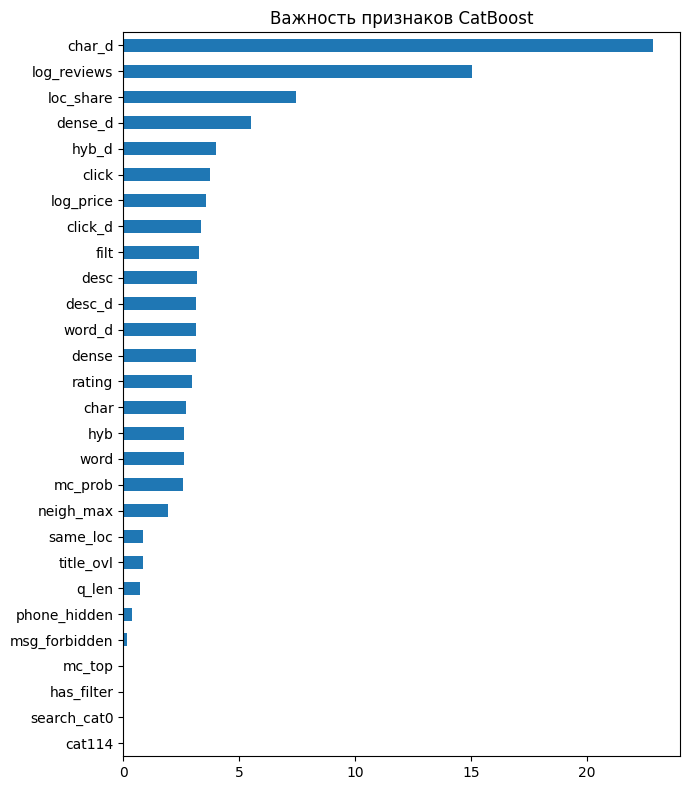

In [15]:
imp = pd.Series(ranker.get_feature_importance(type='PredictionValuesChange'), index=FEATURES).sort_values()
imp.plot.barh(figsize=(7, 8), title='Важность признаков CatBoost'); plt.tight_layout(); plt.show()

### 6.1 Анализ ошибок

Промахи бывают двух типов: объявления нет среди кандидатов, или ранкер не поставил его в топ-50. Ниже доли каждого типа, качество по сегментам запросов и примеры промахов.

In [16]:
qB = val_q[isB].copy()
qB['n_rel'] = qB.rel.str.len()
qB['recall'] = [len(set(predB_rank[i]) & set(r)) / len(r) for i, r in zip(qB.index, qB.rel)]
qB['cand_recall'] = cand_recall[isB].values

# Типы ошибок в штуках релевантных объявлений
n_rel = qB.n_rel.sum()
n_in_cand = (qB.cand_recall * qB.n_rel).sum()
n_in_top = (qB.recall * qB.n_rel).sum()
display(pd.DataFrame({
    'объявлений': [n_rel, n_in_top, n_in_cand - n_in_top, n_rel - n_in_cand],
}, index=['релевантных всего', 'пойманы в топ-50', 'промах ранжирования', 'промах кандидатогенерации']).assign(
    доля=lambda d: (d['объявлений'] / n_rel).round(3)))

# Сегменты запросов
title_of = dict(zip(val_ix.ids, val_ix.items.item_title_raw))
loc_of = dict(zip(val_ix.ids, val_ix.items.item_location_id))
fit_texts = set(fit.t_q)
segments = {
    'текст запроса встречался в train': qB.t_q.isin(fit_texts),
    'релевантное в той же локации, что поиск': pd.Series([all(loc_of[i] == L for i in r) for r, L in
                                                          zip(qB.rel, qB.search_location_id)], index=qB.index),
    'у запроса есть фильтры': qB.t_f != '',
    'запрос из одного слова': qB.t_q.str.split().str.len() == 1,
    'больше одного релевантного': qB.n_rel > 1,
}
seg_rows = []
for name, mask in segments.items():
    for val in (True, False):
        m = mask == val
        seg_rows.append({'сегмент': name, 'значение': 'да' if val else 'нет', 'доля запросов': m.mean(),
                         'Recall@50': qB.recall[m].mean(), 'потолок кандидатов': qB.cand_recall[m].mean()})
display(pd.DataFrame(seg_rows).round(3))

# Примеры полных промахов: запрос, что было нужно, что ранкер поставил первым
miss = qB[qB.recall == 0].sample(min(12, (qB.recall == 0).sum()), random_state=CFG['SEED'])
pd.DataFrame({
    'запрос': miss.search_query.values,
    'фильтры': miss.search_infm_params_text.values,
    'релевантное объявление': [title_of[r[0]] for r in miss.rel],
    'в кандидатах': (miss.cand_recall > 0).values,
    'топ-1 ранкера': [title_of[predB_rank[i][0]] if predB_rank[i] else '' for i in miss.index],
})

,объявлений,доля
релевантных всего,2639.0,1.000
пойманы в топ-50,2253.0,0.854
промах ранжирования,189.0,0.072
промах кандидатогенерации,197.0,0.075


,сегмент,значение,доля запросов,Recall@50,потолок кандидатов
0,текст запроса встречался в train,да,0.378,0.885,0.945
1,текст запроса встречался в train,нет,0.622,0.839,0.915
2,"релевантное в той же локации, что поиск",да,0.745,0.930,0.978
3,"релевантное в той же локации, что поиск",нет,0.255,0.640,0.774
4,у запроса есть фильтры,да,0.508,0.874,0.932
5,у запроса есть фильтры,нет,0.492,0.838,0.921
6,запрос из одного слова,да,0.047,0.777,0.901
7,запрос из одного слова,нет,0.953,0.860,0.928
8,больше одного релевантного,да,0.041,0.849,0.911
9,больше одного релевантного,нет,0.959,0.856,0.927


,запрос,фильтры,релевантное объявление,в кандидатах,топ-1 ранкера
0,отдых на море,,Трансфер. Микроавтобус. Минивен на заказ,True,Отдых на пляже
1,ремонт измельчителя пищевых отходов,,Сантехник с руками из нужного места. Сантехнические услуги с Гарантией,True,Аренда измельчителя веток / Для сада и дачи
2,маникюр приокский район онлайн запись,,Маникюр/педикюр Караваиха,True,"Маникюр,покрытие гель лаком"
3,автоняня сопровождение детей,,Трезвый водитель 24/7,True,Автоняня/ Сопровождение детей/ Трезвый водитель
4,установка руля bmw,,"Дооснащение BMW, Mini и Rolls-Royce",True,Активация скрытых функций BMW
5,аренда автокрана 100 тонн,,"Аренда и услуги автокрана, 230 т, 75 м",False,"Аренда и услуги автокрана, 30 т, 23 м, с гуськом 13 м"
6,подростковый онлайн психолог,,Психолог онлайн,False,Детский и подростковый психолог онлайн 6–17 лет
7,рыболка,,Рыбалка и отдых,True,Рыбалка
8,стяжка пола кладка перегородок,Вид услуги Ремонт и отделка,Черновой ремонт квартир,False,Стяжка полов
9,скупка стабилизатора напряжения,,Скупка с выездом : Радиодеталей Плат Приборов СССР,True,Ремонт стабилизаторов напряжения и ибп


### Финальный ранкер

Для бенчмарка ранкер переобучается на A∪B с теми же параметрами.

In [17]:
trAB = val_cands[val_cands.groupby('qi').label.transform('sum') > 0]
final_ranker = CatBoostRanker(**{**ranker_params, 'verbose': 200})
final_ranker.fit(make_pool(trAB))

# освобождаем память валидационного корпуса перед бенчмарком
del val_ix, val_kn, val_cands, trA, teB, trAB, fit; _ = gc.collect()

0:	total: 1.79s	remaining: 23m 49s
200:	total: 4m	remaining: 11m 56s
400:	total: 8m 24s	remaining: 8m 21s
600:	total: 13m 15s	remaining: 4m 23s
799:	total: 17m 8s	remaining: 0us


## 7. Ответ на бенчмарк

Знания считаются по всему train, индекс строится по `benchmark_items`. Дальше выполняются те же шаги, что на валидации.

In [18]:
bench_items_p = prepare_items(bench_items)
bench_ix = CorpusIndex(bench_items_p, 'bench')
bench_kn = SearchKnowledge(train, bench_ix)
bench_cands, _ = retrieve(bench_q, bench_ix, bench_kn, 'bench')

bench_scores = final_ranker.predict(bench_cands[FEATURES].astype(np.float32))
predictions = top50_from_scores(bench_cands, bench_scores, bench_ix.ids, len(bench_q))

# Страховка: если у запроса меньше 50 кандидатов, добиваем по гибридному скору (на практике не срабатывает)
hyb_order = top50_from_scores(bench_cands, bench_cands.hyb.values, bench_ix.ids, len(bench_q))
for q in range(len(predictions)):
    if len(predictions[q]) < 50:
        extra = [i for i in hyb_order[q] if i not in set(predictions[q])]
        predictions[q] = (predictions[q] + extra)[:50]

answer = pd.DataFrame({'query_id': bench_q.query_id.values,
                       'answer': [' '.join(top50) for top50 in predictions]})
out_path = 'answer.csv'
answer.to_csv(out_path, index=False)
answer.head()

[bench] индекс корпуса готов за 60s
знания из 497673 строк / 73706 текстов готовы за 28s
  64/2452 запросов, 7s
  704/2452 запросов, 44s
  1344/2452 запросов, 82s
  1984/2452 запросов, 116s
[bench] 799892 кандидатов (326 на запрос) за 144s


,query_id,answer
0,70DfDUpwjxB4lzFd,a1df0525799ab4b5 d722bcda1a555091 355392014208b7bf f4e8903d7689e222 255fbeaf...
1,JTrdTaZJvSiLPkXj,422d3ffdd5bbf626 f46f68aaa4d7de38 cbeccbecb1fb8d86 1c6d2079e07f4497 367af128...
2,LZCZNoVG4AFUkVRJ,168a9207e80b0be4 d62074dd39caefee d8fce513e4f000a7 edecb3695ab88901 dab52187...
3,660ac9QVtXkRxZC3,af91ec4a29b66636 bd2cb4500fad728e 4c15e7abba063ac5 a846a2a5241e1180 1e5924dc...
4,YgHcM9MVbxKnxD1e,13f58fe9542bdb1a 615c73ea4c3bfd15 ba78ad593ec3412d 9c41fe789f98d702 1a626343...


## 8. Описание решения

**Данные и признаки**

- Текст и фильтры запроса; заголовок, параметры и начало описания объявления — основной сигнал.
- Локация учитывается через приор из train: часть запросов задана регионом.
- История поиска из train используется на уровне похожих запросов: что по ним выбирали и в каких микрокатегориях. Сами item_id из train в корпусе почти не встречаются.
- Рейтинг, отзывы, цена и флаги объявления — дополнительные признаки для ранкера.
- Не используются `search_is_delivery_search` (в бенчмарке всегда 0) и координаты (их заменяет локация).

**Модели**

- Кандидаты: TF-IDF (scikit-learn), эмбеддинги `sergeyzh/rubert-tiny-turbo` (sentence-transformers, лицензия MIT), сигнал похожих запросов.
- Ранжирование: CatBoost YetiRank по 28 признакам.
- Всё работает локально, модель один раз скачивается с Hugging Face.

**Проверка качества**

Псевдо-бенчмарк из train (раздел 4): ранкер обучен на A, оценён на B.

| этап | Recall@50 на B |
|---|---|
| лучший источник (`click`) | 0.752 |
| смесь источников | 0.763 |
| CatBoost | **0.856** |
| потолок кандидатов | 0.926 |

На платформе получено 0.847.

**Найденные ошибки и что сделано**

- Запросы с локацией-регионом → мягкий приор локации вместо фильтра.
- Опечатки и словоформы → символьные n-граммы, эмбеддинги, стемы.
- Короткие неоднозначные запросы → сигнал похожих запросов и приор микрокатегории.
- Основной оставшийся промах — объявления из другой локации: 25% запросов, Recall@50 0.64. Буст локации их опускает.